In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('concertriccir2.xls')

In [3]:
df.head()

,X,Y,class
0,0.70,-0.247,0.0
1,-3.95,2.740,1.0
2,0.15,-2.160,1.0
3,-1.67,-0.942,1.0
4,2.56,-1.850,1.0


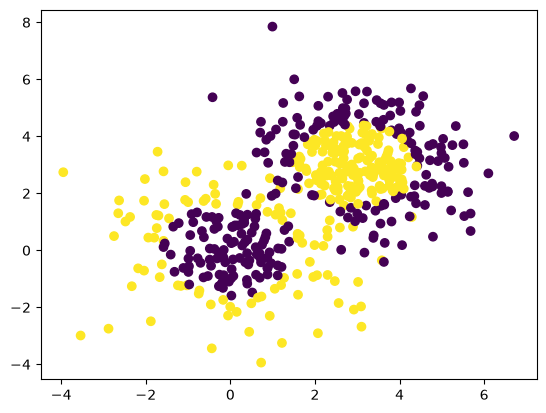

In [7]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [8]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

In [10]:
model1=Sequential()

model1.add(Input(shape=(2,)))
model1.add(Dense(2,activation='relu'))
model1.add(Dense(2,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
adam=Adam(learning_rate=0.01)

In [14]:
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [15]:
history1=model1.fit(X,y,validation_split=0.2,epochs=200)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.4300 - loss: 0.6952 - val_accuracy: 0.5200 - val_loss: 0.6928
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5325 - loss: 0.6938 - val_accuracy: 0.4300 - val_loss: 0.6949
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5025 - loss: 0.6931 - val_accuracy: 0.4300 - val_loss: 0.6975
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.6921 - val_accuracy: 0.4300 - val_loss: 0.6988
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5050 - loss: 0.6917 - val_accuracy: 0.4300 - val_loss: 0.7008
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4925 - loss: 0.6914 - val_accuracy: 0.4300 - val_loss: 0.7023
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4925 - loss: 0.6910 - val_accuracy: 0.4300 - val_loss: 0.7038
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4825 - loss: 0.6910 - val_accuracy: 0.

In [16]:
model2 = Sequential()

model2.add(Input(shape=(2,)))
model2.add(Dense(3,activation='relu'))
model2.add(BatchNormalization())
model2.add(Dense(2,activation='relu'))
model2.add(BatchNormalization())
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 3)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 3)                   │              12 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 2)                   │               8 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 2)                   │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [19]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
history2=model2.fit(X,y,validation_split=0.2,epochs=200)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5250 - loss: 0.6785 - val_accuracy: 0.5600 - val_loss: 0.7410
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5525 - loss: 0.6752 - val_accuracy: 0.5300 - val_loss: 0.7316
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5700 - loss: 0.6702 - val_accuracy: 0.5100 - val_loss: 0.7221
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5425 - loss: 0.6690 - val_accuracy: 0.4800 - val_loss: 0.7136
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6175 - loss: 0.6645 - val_accuracy: 0.4700 - val_loss: 0.7054
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6350 - loss: 0.6639 - val_accuracy: 0.4500 - val_loss: 0.6978
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6050 - loss: 0.6638 - val_accuracy: 0.4300 - val_loss: 0.6906
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6400 - loss: 0.6557 - val_accuracy: 0.

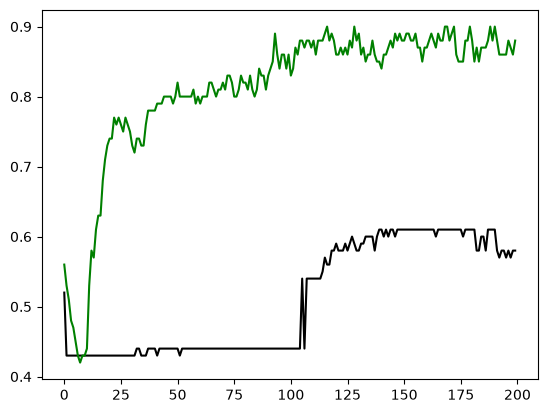

In [20]:
plt.plot(history1.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')